### Feature Extraction

In [2]:
# are we using a gpu?
!nvidia-smi

Tue May 19 14:39:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Download and become one with data

In [3]:
# get data (10% of 10 food classes)
import zipfile

# download the data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

# unzip the downloaded file
zip_ref = zipfile.ZipFile("10_food_classes_10_percent.zip")
zip_ref.extractall()
zip_ref.close()

--2026-05-19 14:39:09--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.188.207, 192.178.163.207, 173.194.202.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.188.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   173MB/s    in 0.9s    

2026-05-19 14:39:10 (173 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [4]:
# how many images in each folder
import os

# walk though dir and list number of files
for dirpath, dirnames, filenames in os.walk("10_food_classes_10_percent"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_curry'.
There are 0 directories and 75 images in '10_food_classes_10_percent

create data loaders (prep the data)

In [5]:
# setup data inputs
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# usually in ml all caps indicates hyperparameters
IMG_SHAPE = (224, 224)
BATCH_SIZE = 32

train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

print("Training Images:")
train_data_10_percent = train_datagen.flow_from_directory(train_dir,
                                                             target_size = IMG_SHAPE,
                                                             batch_size = BATCH_SIZE,
                                                             class_mode = "categorical")

print("Testing Images:")
test_data_10_percent = test_datagen.flow_from_directory(test_dir,
                                                             target_size = IMG_SHAPE,
                                                             batch_size = BATCH_SIZE,
                                                             class_mode = "categorical")

Training Images:
Found 750 images belonging to 10 classes.
Testing Images:
Found 2500 images belonging to 10 classes.


In [6]:
# Create a separate data generator for EfficientNet (NO RESCALING)
# EfficientNet models in tf.keras.applications have rescaling built-in
efficientnet_datagen = ImageDataGenerator()

train_data_efficientnet = efficientnet_datagen.flow_from_directory(train_dir,
                                                                  target_size=IMG_SHAPE,
                                                                  batch_size=BATCH_SIZE,
                                                                  class_mode='categorical')

test_data_efficientnet = efficientnet_datagen.flow_from_directory(test_dir,
                                                                 target_size=IMG_SHAPE,
                                                                 batch_size=BATCH_SIZE,
                                                                 class_mode='categorical')

Found 750 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


In [7]:
train_data_10_percent.class_indices

{'chicken_curry': 0,
 'chicken_wings': 1,
 'fried_rice': 2,
 'grilled_salmon': 3,
 'hamburger': 4,
 'ice_cream': 5,
 'pizza': 6,
 'ramen': 7,
 'steak': 8,
 'sushi': 9}

In [8]:
train_data_10_percent.num_classes

10

Setting up callbacks

In [9]:
# create Tensorboard callback function

import datetime

def create_tensorboard_callback(dir_name, model_name):
  # log dir -> where to save log files to be seen by tensorboard
  log_dir = dir_name + "/" + model_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = log_dir)
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback

Creating models using tf.keras.applications

In [10]:
# import dependences
import tensorflow as tf
from tensorflow.keras import layers

In [11]:
def create_model(base_model_class, num_classes):
    base_model = base_model_class(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SHAPE + (3,),
        pooling="avg"
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        layers.Dense(num_classes, activation="softmax", name="output_layer")
    ])
    return model


In [12]:
efficientnet_model = create_model(tf.keras.applications.EfficientNetB0,
                                  num_classes=train_data_10_percent.num_classes)

resnet_model = create_model(tf.keras.applications.ResNet50V2,
                            num_classes=train_data_10_percent.num_classes)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Compile the models and Summarize

In [13]:
efficientnet_model.compile(loss="categorical_crossentropy",
optimizer = tf.keras.optimizers.Adam(),
metrics = ["accuracy"])

In [14]:
resnet_model.compile(loss="categorical_crossentropy",
optimizer = tf.keras.optimizers.Adam(),
metrics = ["accuracy"])

In [15]:
efficientnet_model.summary()
resnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 2048)           │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,585,290 (89.97 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

FIt and Validate the model

In [16]:
resnet_history = resnet_model.fit(train_data_10_percent,
                                  epochs = 5,
                                  steps_per_epoch = len(train_data_10_percent),
                                  validation_data = test_data_10_percent,
                                  validation_steps = len(test_data_10_percent),
                                  callbacks = [create_tensorboard_callback("training_logs", "resnet50v2")])

Saving TensorBoard log files to: training_logs/resnet50v2/20260519-143923
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.3267 - loss: 2.0251 - val_accuracy: 0.5756 - val_loss: 1.2709
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 438ms/step - accuracy: 0.7067 - loss: 0.9720 - val_accuracy: 0.6960 - val_loss: 0.9247
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 414ms/step - accuracy: 0.7987 - loss: 0.6908 - val_accuracy: 0.7472 - val_loss: 0.8006
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 401ms/step - accuracy: 0.8547 - loss: 0.5294 - val_accuracy: 0.7608 - val_loss: 0.7502
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 388ms/step - accuracy: 0.9053 - loss: 0.4278 - val_accuracy: 0.7584 - val_loss: 0.7384


In [17]:
import matplotlib.pyplot as plt
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

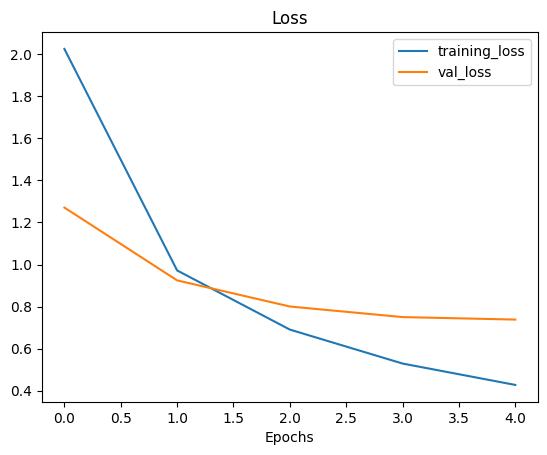

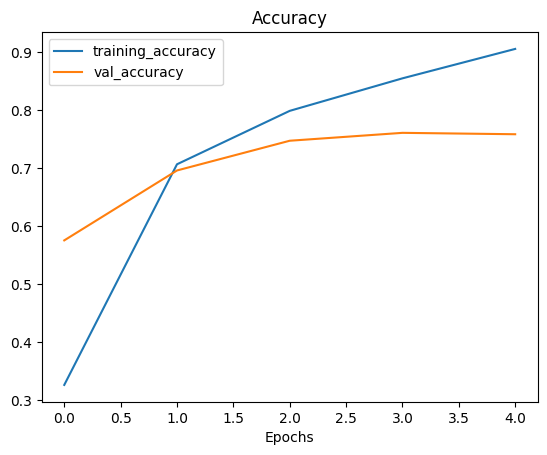

In [18]:
plot_loss_curves(resnet_history)

In [19]:
efficientnet_history = efficientnet_model.fit(train_data_10_percent,
                                  epochs = 5,
                                  steps_per_epoch = len(train_data_10_percent),
                                  validation_data = test_data_10_percent,
                                  validation_steps = len(test_data_10_percent),
                                  callbacks = [create_tensorboard_callback("training_logs", "EfficientNetB0")])

Saving TensorBoard log files to: training_logs/EfficientNetB0/20260519-144045
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.0840 - loss: 2.3608 - val_accuracy: 0.1000 - val_loss: 2.3264
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 378ms/step - accuracy: 0.1067 - loss: 2.3315 - val_accuracy: 0.1000 - val_loss: 2.3152
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 380ms/step - accuracy: 0.0920 - loss: 2.3255 - val_accuracy: 0.1000 - val_loss: 2.3147
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 349ms/step - accuracy: 0.0893 - loss: 2.3379 - val_accuracy: 0.1000 - val_loss: 2.3315
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 376ms/step - accuracy: 0.0907 - loss: 2.3284 - val_accuracy: 0.1000 - val_loss: 2.3235


```markdown
### Re-training EfficientNet with correct input scaling
Now that we've fixed the scaling issue, let's re-fit the model. You should see the accuracy jump significantly in the first epoch.
```

In [20]:
# Re-train EfficientNet with the correct non-rescaled data
efficientnet_history = efficientnet_model.fit(train_data_efficientnet,
                                              epochs=5,
                                              steps_per_epoch=len(train_data_efficientnet),
                                              validation_data=test_data_efficientnet,
                                              validation_steps=len(test_data_efficientnet),
                                              callbacks=[create_tensorboard_callback('training_logs', 'EfficientNetB0_fixed')])

Saving TensorBoard log files to: training_logs/EfficientNetB0_fixed/20260519-144233
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 377ms/step - accuracy: 0.4280 - loss: 1.8259 - val_accuracy: 0.7796 - val_loss: 1.1023
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 353ms/step - accuracy: 0.8120 - loss: 0.8862 - val_accuracy: 0.8408 - val_loss: 0.6955
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 373ms/step - accuracy: 0.8493 - loss: 0.6341 - val_accuracy: 0.8616 - val_loss: 0.5809
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 460ms/step - accuracy: 0.8773 - loss: 0.5258 - val_accuracy: 0.8636 - val_loss: 0.5280
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 380ms/step - accuracy: 0.8973 - loss: 0.4611 - val_accuracy: 0.8704 - val_loss: 0.4967


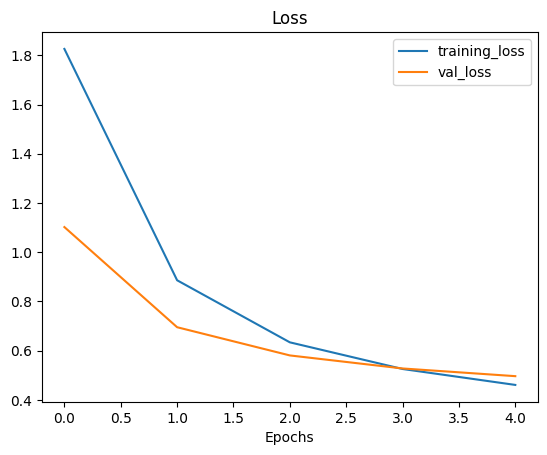

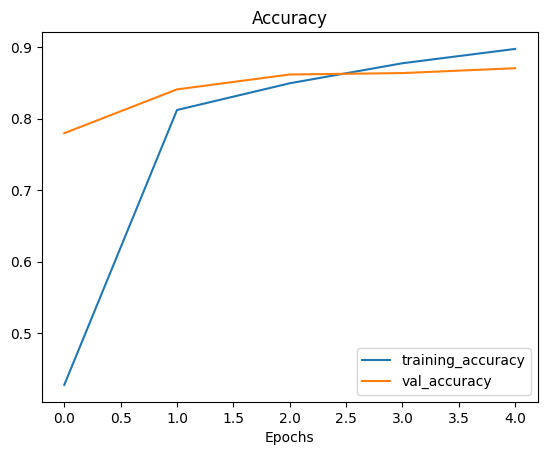

In [21]:
plot_loss_curves(efficientnet_history)

In [22]:
# How many layers does our efficientnetB0 have?

efficientnet_model.layers

In [24]:
len(efficientnet_model.layers[0].weights)

312

###Fine Tuning
